# Análise Exploratória e Pré-processamento de Dados
## Dataset: Taxas dos Títulos Ofertados pelo Tesouro Direto

---

**Disciplina:** Análise de Dados e Boas Práticas  
**Especialização:** Ciência de Dados — PUC  
**Autor:** Marcio Goulart Mocellin  
**Matrícula:** 4052026000399  
**Data:** Março de 2026

---

Este notebook serve como relatório técnico e acadêmico cobrindo as etapas de:
1. Definição do problema
2. Pré-processamento dos dados
3. Análise exploratória dos dados (EDA)

O dataset utilizado é o **Taxas dos Títulos Ofertados pelo Tesouro Direto**, disponibilizado publicamente pelo Tesouro Nacional por meio da plataforma [Tesouro Transparente](https://www.tesourotransparente.gov.br).

---
## 1. Definição do Problema

### 1.1 Descrição do Problema

O **Tesouro Direto** é um programa do Governo Federal brasileiro que permite a compra e venda de títulos públicos federais por pessoas físicas, diretamente pela internet. Os títulos disponíveis incluem opções pós-fixadas e prefixadas, cada uma com características distintas de prazo e rentabilidade.

A escolha do título mais adequado para investimento depende do objetivo do investidor, seja guardar para aposentadoria (Tesouro Renda+ Aposentadoria Extra), investir em educação superior dos filhos (Tesouro Educa+), comprar um imóvel (Tesouro IGPM+ com Juros Semestrais) ou simplesmente obter uma rentabilidade superior à poupança, assim como dependerá do tempo de investimento planejado. Sobre o risco associado, os títulos do Tesouro Direto são considerados os mais baixo risco do mercado, pois são garantidos pelo Tesouro Nacional.

Outros investimentos, como ações, fundos imobiliários e criptomoedas, podem oferecer potencial de retorno mais elevado, mas também apresentam maior volatilidade e risco de perda. Dessa forma, o investidor deve ponderar o risco e o retorno esperado antes de escolher sobre o quanto deseja investir nesses títulos. A alternativa mais sábia é diversificar a carteira de investimentos, usando os titulos do Tesouro para diluir o risco da carteira com investimentos mais arriscados, mas com potencial de retorno mais elevado.

Este trabalho utiliza o dataset de **preços e taxas diários** dos títulos ofertados no Tesouro Direto, cujo objetivo analítico é entender o comportamento histórico das taxas de rentabilidade e preços unitários, identificar padrões sazonais e tendências de longo prazo, e preparar os dados para modelos preditivos futuros. Não se pretende trabalhar com um titulo específico, mas sim analisar o comportamento geral do mercado de títulos públicos ao longo do tempo. Já se sabe de antemão que a análise agregada dos títulos mascarará comportamentos específicos de cada título e aumentará a variância dos dados como um todo, o que dificultará a identificação de padrões e tendências.

**Fonte do dataset:**
- CSV: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv
- Metadados: https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/1a8eb2e3-4902-4a38-a1eb-6410f23d90de/download/taxa.pdf

### 1.2 Tipo de Problema

Trata-se predominantemente de um problema de **aprendizado não supervisionado** nesta etapa: não há uma variável-alvo explícita para previsão imediata. A análise exploratória busca descobrir padrões, agrupamentos e tendências nos dados. Em etapas futuras, o problema poderia ser reformulado como **supervisionado** para, por exemplo, prever a taxa de um título para determinada o melhormomento de compra de um título.

### 1.3 Hipóteses e Premissas

- **H1:** As taxas dos títulos apresentam correlação com o cenário macroeconômico, exibindo variações mais acentuadas em períodos de crise (2015–2016, 2020).
- **H2:** Os títulos indexados ao IPCA (Tesouro IPCA+) apresentam maior variabilidade nas taxas do que os títulos prefixados.
- **H3:** Há uma correlação negativa entre a taxa de rentabilidade e o preço unitário do título: quanto maior a taxa, menor o preço.
- **H4:** Títulos com prazos de vencimento mais longos tendem a oferecer taxas mais elevadas como prêmio de risco.
- **H5:** A sazonalidade pode influenciar as taxas, com variações mais significativas em determinado dia da semana, dia do mês ou mês do ano.

### 1.4 Restrições para Seleção dos Dados

- Serão considerados **todos os registros históricos** disponíveis no dataset sem filtro de período inicial.
- Serão retirados da analise os titulos que possam apresentar dados inconsistentes ou incompletos.

### 1.5 Definição dos Atributos

| Atributo | Tipo | Descrição |
|---|---|---|
| `Tipo Titulo` | Categórico (nominal) | Nome comercial do título público |
| `Data Vencimento` | Data | Data em que o título vence e o investidor recebe o valor de face |
| `Data Base` | Data | Data de referência do registro (data do pregão) |
| `Taxa Compra Manha` | Numérico (contínuo) | Taxa de compra registrada no período da manhã, em % ao ano |
| `Taxa Venda Manha` | Numérico (contínuo) | Taxa de venda registrada no período da manhã, em % ao ano |
| `PU Compra Manha` | Numérico (contínuo) | Preço unitário de compra — manhã, em R$ |
| `PU Venda Manha` | Numérico (contínuo) | Preço unitário de venda — manhã, em R$ |
| `PU Base Manha` | Numérico (contínuo) | Preço unitário base (valor de referência) — manhã, em R$ |

Observação: No arquivo fornecido as variaveis contínuas apresentam no máximo duas casas após a vírgula

---
## 2. Importação de Bibliotecas

As bibliotecas escolhidas são amplamente utilizadas na comunidade de ciência de dados com Python e já estão disponíveis no Google Colab sem necessidade de instalação adicional.

In [1]:
import warnings

import numpy as np
import pandas as pd
import datetime as dt
import holidays
from matplotlib import __version__ as matversion
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn import __version__ as skversion
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Configurações globais de visualização
# warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("Hoje é dia", dt.datetime.now().strftime("%Y-%m-%d"))
print("Bibliotecas importadas com sucesso.")
print(f"  pandas  : {pd.__version__}")
print(f"  numpy   : {np.__version__}")
print(f"  seaborn : {sns.__version__}")
print(f"  matplotlib : {matversion}")
print(f"  sklearn : {skversion}")

Hoje é dia 2026-03-18
Bibliotecas importadas com sucesso.
  pandas  : 2.2.2
  numpy   : 2.0.2
  seaborn : 0.13.2
  matplotlib : 3.10.0
  sklearn : 1.6.1


---
## 3. Carregamento e Inspeção Inicial dos Dados

### 3.1 Carregamento do Dataset

O arquivo CSV é carregado diretamente da URL pública do Tesouro Transparente. O separador utilizado é o ponto e vírgula (`;`) e o separador decimal é a vírgula (`,`), padrão brasileiro. As colunas de data são convertidas automaticamente para o tipo `datetime`.

In [2]:
URL = (
    "https://www.tesourotransparente.gov.br/ckan/dataset/"
    "df56aa42-484a-4a59-8184-7676580c81e3/resource/"
    "796d2059-14e9-44e3-80c9-2d9e30b405c1/download/precotaxatesourodireto.csv"
)

df_raw = pd.read_csv(
    URL,
    sep=";",
    decimal=",",
    parse_dates=["Data Vencimento", "Data Base"],
    dayfirst=True,
)

print(f"Dataset carregado com sucesso.")
print(f"Dimensões: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]} colunas")

Dataset carregado com sucesso.
Dimensões: 168,758 linhas x 8 colunas


### 3.2 Primeiras Linhas

Inspecionamos as cinco primeiras linhas para verificar se o carregamento ocorreu corretamente e identificar eventuais problemas óbvios.

In [3]:
df_raw.head()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
0,Tesouro Prefixado com Juros Semestrais,2011-01-01,2009-06-12,10.28,10.33,1039.94,1039.28,1038.87
1,Tesouro Prefixado com Juros Semestrais,2010-07-01,2009-06-12,9.58,9.62,1048.28,1047.91,1047.53
2,Tesouro Prefixado com Juros Semestrais,2010-01-01,2009-06-12,9.06,9.10,1048.08,1047.87,1047.51
3,Tesouro Prefixado com Juros Semestrais,2013-01-01,2009-06-12,12.00,12.06,990.45,988.89,988.45
4,Tesouro Prefixado com Juros Semestrais,2014-01-01,2009-06-12,12.28,12.34,969.83,967.98,967.53


### 3.3 Últimas Linhas

In [4]:
df_raw.tail()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
168753,Tesouro IGPM+ com Juros Semestrais,2006-12-01,2006-11-28,11.15,11.17,2037.06,2037.06,2035.64
168754,Tesouro IGPM+ com Juros Semestrais,2017-07-01,2006-11-28,8.18,8.26,1656.34,1647.15,1646.18
168755,Tesouro IGPM+ com Juros Semestrais,2021-04-01,2006-11-28,8.01,8.09,1597.19,1586.29,1585.37
168756,Tesouro IGPM+ com Juros Semestrais,2031-01-01,2006-11-28,7.92,8.02,2780.01,2754.06,2752.46
168757,Tesouro Prefixado com Juros Semestrais,2008-01-01,2006-11-28,13.00,13.04,1012.95,1012.59,1012.09


### 3.4 Tipos de Dados e Informações Gerais

Verificamos os tipos de cada coluna e a presença de valores nulos.

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168758 entries, 0 to 168757
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   Tipo Titulo        168758 non-null  object        
 1   Data Vencimento    168758 non-null  datetime64[ns]
 2   Data Base          168758 non-null  datetime64[ns]
 3   Taxa Compra Manha  168758 non-null  float64       
 4   Taxa Venda Manha   168758 non-null  float64       
 5   PU Compra Manha    168758 non-null  float64       
 6   PU Venda Manha     168758 non-null  float64       
 7   PU Base Manha      168758 non-null  float64       
dtypes: datetime64[ns](2), float64(5), object(1)
memory usage: 10.3+ MB


**Observações sobre a inspeção inicial:**

- O dataset possui **8 colunas** e um número expressivo de linhas, acumulando registros diários desde o início do programa Tesouro Direto.
- As colunas de data (`Data Vencimento`, `Data Base`) foram corretamente interpretadas como `datetime64[ns]`.
- As colunas numéricas foram lidas como `float64` graças à configuração do separador decimal.
- A coluna `Tipo Titulo` é do tipo `object` (string), o que é esperado para dados categóricos nominais.


---
## 5. Pré-processamento dos Dados

### 5.1 Visão Geral das Operações

Com base na análise exploratória, as seguintes operações de pré-processamento são realizadas:

1. **Análise de zeros** — valores zero nas colunas numéricas podem indicar ausência de cotação, assim como valores muito próximos de zero.
2. **Remoção de registros com todos os valores numéricos ausentes** — registros totalmente vazios não contribuem para a análise.
3. **Engenharia de atributos** — criação de novas colunas derivadas úteis para análise.
4. **Normalização (Min-Max Scaling)** — escala todos os atributos numéricos para o intervalo [0, 1].
5. **Padronização (Z-score)** — transforma os atributos para média 0 e desvio-padrão 1.
6. **Discretização das taxas** — converte as taxas contínuas em faixas categóricas ordinais.
7. **One-hot encoding do Tipo Título** — transforma a variável categórica em colunas binárias.

### 5.2 Análise de zeros

Quando se depara com valores zerados em colunas numéricas tem que se investigar o motivo. É muito comum que valores zerados em datasets financeiros intiquem o truncamento do valor real do titulo, ou seja, o valor real no titulo é muito baixo, mas o sistema de coleta de dados não consegue registrar o valor real e acaba registrando como zero.  

#### 5.2.1 Indícios de truncamento de dados

In [6]:
df_zero = df_raw.loc[(df_raw['Taxa Compra Manha'] == 0), ['Tipo Titulo', 'Data Vencimento', 'Data Base']].sort_values(by='Data Base', ascending=False)

feriados_br = holidays.Brazil(
    years=sorted(df_zero["Data Base"].dt.year.unique())
)
# Extrair dia da semana (0=segunda, 6=domingo)
df_zero["dia_semana"] = df_zero["Data Base"].dt.dayofweek
df_zero["nome_dia"] = df_zero["Data Base"].dt.day_name()

# Mapear para português
mapa_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}
df_zero["dia_semana_pt"] = df_zero["dia_semana"].map(mapa_dias)
datas_base = df_zero["Data Base"].dt.normalize()
df_zero["eh_feriado"] = datas_base.map(lambda data: data in feriados_br)
# df_zero["nome_feriado"] = datas_base.map(lambda data: feriados_br.get(data))
df_zero

,Tipo Titulo,Data Vencimento,Data Base,dia_semana,nome_dia,dia_semana_pt,eh_feriado
29138,Tesouro Selic,2027-03-01,2026-03-17,1,Tuesday,Terça,False
29199,Tesouro Selic,2027-03-01,2026-03-16,0,Monday,Segunda,False
29513,Tesouro Selic,2027-03-01,2026-03-13,4,Friday,Sexta,False
29829,Tesouro Selic,2027-03-01,2026-03-12,3,Thursday,Quinta,False
29891,Tesouro Selic,2027-03-01,2026-03-11,2,Wednesday,Quarta,False
...,...,...,...,...,...,...,...
159609,Tesouro Selic,2006-01-18,2005-11-22,1,Tuesday,Terça,False
159638,Tesouro Selic,2006-01-18,2005-11-21,0,Monday,Segunda,False
14091,Tesouro Selic,2005-02-16,2005-01-04,1,Tuesday,Terça,False
14119,Tesouro Selic,2005-02-16,2005-01-03,0,Monday,Segunda,False


In [7]:
print(f"Total de registros com Taxa Compra Manhã = 0: {len(df_zero):,}")
print(f"Distribuição por dia da semana:")
print(df_zero["dia_semana_pt"].value_counts())
print(f"\nTotal de registros que caem em feriados: {df_zero['eh_feriado'].sum()}")
del df_zero, feriados_br, mapa_dias, datas_base

Total de registros com Taxa Compra Manhã = 0: 7,692
Distribuição por dia da semana:
dia_semana_pt
Quarta     1567
Quinta     1536
Sexta      1536
Terça      1532
Segunda    1521
Name: count, dtype: int64

Total de registros que caem em feriados: 0


A observação de registros com taxa de compra igual a zero, não ocorreram em eventos como feriados, finais de semana ou outros fatores externos, mas em dias ordinários, o que sugere que esses valores zerados podem ser resultado do truncamento de dados, indicando que o valor real da taxa era muito próximo de zero para ser registrado corretamente.  
Agora analizaremos a vizinhança desses registros para entender melhor o comportamento dos dados.

In [8]:
df_raw.loc[(df_raw['Tipo Titulo'] == 'Tesouro Selic') & (df_raw['Data Vencimento'] == '2026-03-01 00:00:00') & (df_raw['Data Base'].isin(pd.date_range('2025-12-17', '2025-12-30'))), :].sort_values(by='Data Base', ascending=False)


,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
29712,Tesouro Selic,2026-03-01,2025-12-30,0.01,0.02,18095.50,18075.13,18075.13
30025,Tesouro Selic,2026-03-01,2025-12-29,0.01,0.02,18075.61,18065.28,18065.28
30338,Tesouro Selic,2026-03-01,2025-12-26,0.01,0.02,18065.72,18055.38,18055.38
30395,Tesouro Selic,2026-03-01,2025-12-23,0.00,0.01,18055.83,18035.49,18035.49
25385,Tesouro Selic,2026-03-01,2025-12-22,0.01,0.02,18035.88,18025.53,18025.53
25604,Tesouro Selic,2026-03-01,2025-12-19,0.01,0.02,18025.92,18015.58,18015.58
25664,Tesouro Selic,2026-03-01,2025-12-18,0.01,0.02,18015.95,18005.60,18005.60
25976,Tesouro Selic,2026-03-01,2025-12-17,0.01,0.02,18005.93,17995.59,17995.59


O valor de zero na serie temporal `Taxa Compra Manha` na Data Base de 2025-12-23 está cercado por registros com taxas muito próximas de zero, reforçando a hipótese de truncamento de dados.

#### 5.2.2 Riscos inerentes ao truncamento de dados

Inicialmente se observará o histograma da coluna `Taxa Venda Manha` para verificar a distribuição dos valores.

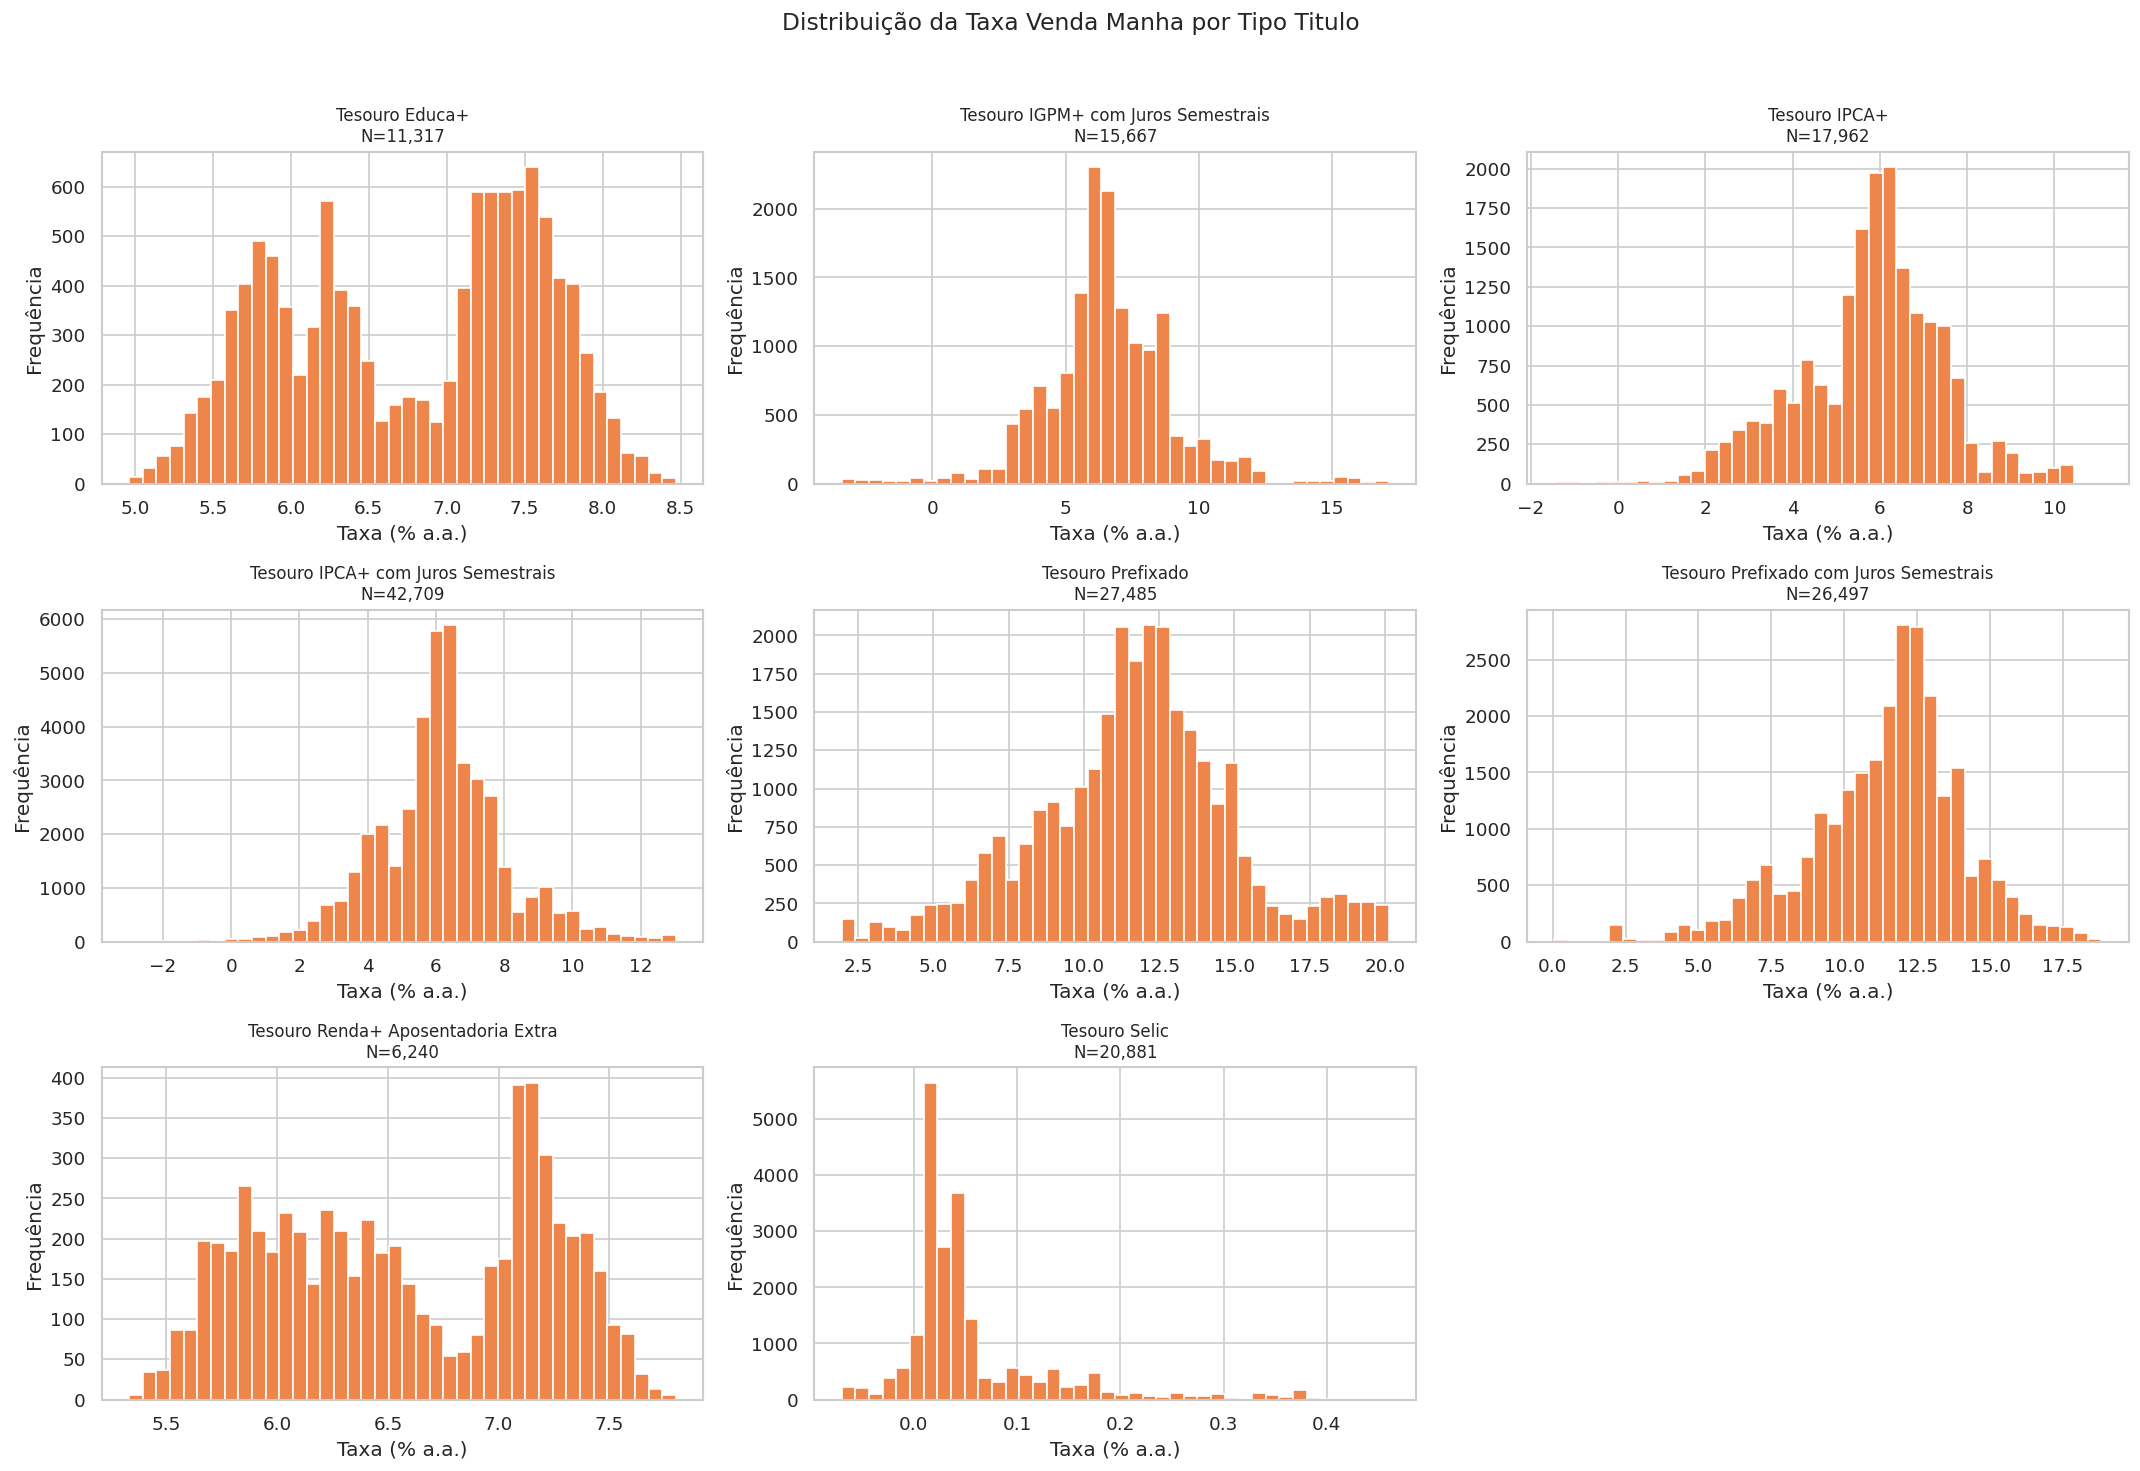

In [9]:
# Histograma de Taxa Venda Manha por Tipo Titulo

tipos = sorted(df_raw["Tipo Titulo"].dropna().unique())

n_cols = 3
n_rows = int(np.ceil(len(tipos) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

cor = sns.color_palette("muted")[1]

for i, tipo in enumerate(tipos):
    ax = axes[i]
    subset = df_raw.loc[df_raw["Tipo Titulo"] == tipo, "Taxa Venda Manha"].dropna()
    ax.hist(subset, bins=40, color=cor, edgecolor="white")
    ax.set_title(f"{tipo}\nN={len(subset):,}", fontsize=10)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")

# Esconde eixos sobrando (quando grade > quantidade de tipos)
for j in range(len(tipos), len(axes)):
    axes[j].axis("off")

plt.suptitle("Distribuição da Taxa Venda Manha por Tipo Titulo", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Como o titulo `Tesouro Selic` apresenta se muito centrado em valores próximos de zero e sua dispersão é muito baixa, na casa dos décimos, a presença de truncamento de dados pode distorcer significativamente as análises estatísticas e os modelos preditivos, levando a conclusões errôneas sobre o comportamento das taxas e preços dos títulos. Desta forma se preferirá remover este titulo da análise, pois ele não apresenta segurança suficiente para contribuir com insights relevantes e pode introduzir ruído nos modelos preditivos.

In [10]:
df_pre = df_raw.loc[~(df_raw['Tipo Titulo'] == 'Tesouro Selic'), :]

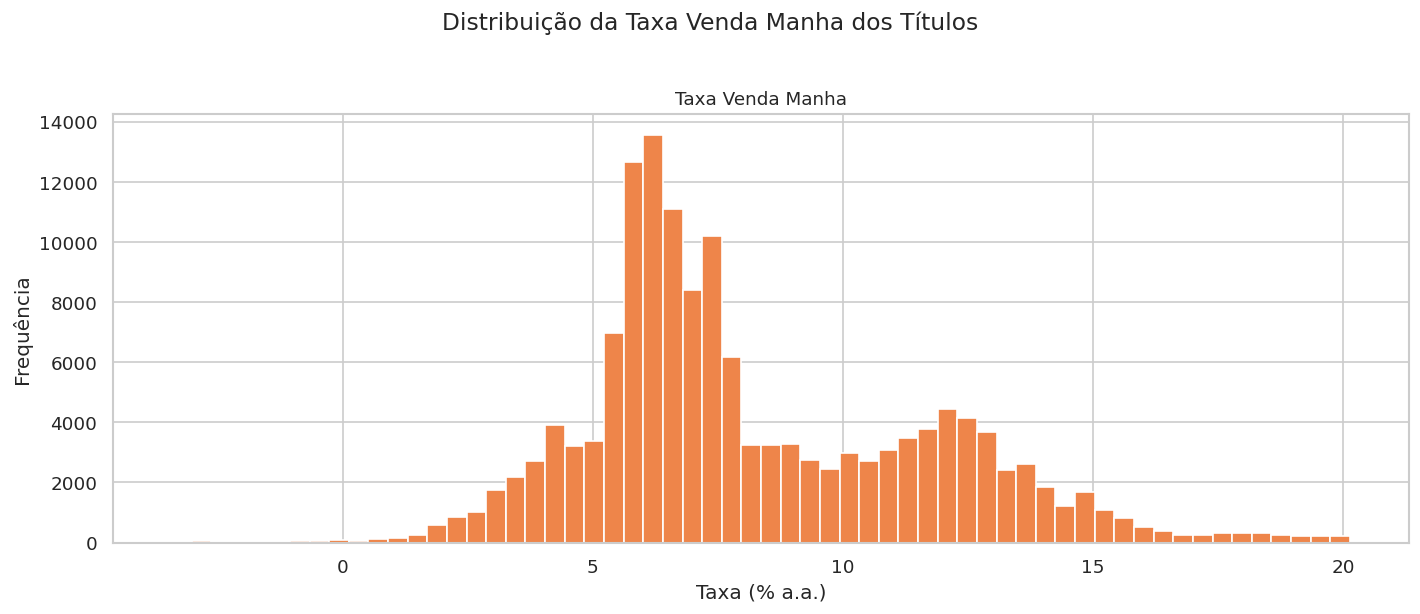

In [11]:

df_pre["Taxa Venda Manha"].hist(bins=60, color=sns.color_palette("muted")[1], edgecolor="white")
plt.title("Taxa Venda Manha", fontsize=11)
plt.xlabel("Taxa (% a.a.)")
plt.ylabel("Frequência")
plt.suptitle("Distribuição da Taxa Venda Manha dos Títulos", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [12]:
colunas_numericas = df_pre.select_dtypes(include="number").columns.tolist()

print("Zeros encontrados nas colunas numéricas:")
for col in colunas_numericas:
    zeros_antes = (df_pre[col] == 0).sum()
    
    # df_pre[col] = df_pre[col].replace(0, np.nan)
    print(f"  {col:25s}: {zeros_antes:5,} zeros")

print(f"\nTotal de linhas com zeros: {(df_pre == 0).sum().sum():,}")
print(f"Dimensões do dataset: {df_pre.shape[0]:,} linhas x {df_pre.shape[1]} colunas")

Zeros encontrados nas colunas numéricas:
  Taxa Compra Manha        :    15 zeros
  Taxa Venda Manha         :     1 zeros
  PU Compra Manha          :    49 zeros
  PU Venda Manha           :    48 zeros
  PU Base Manha            :    29 zeros

Total de linhas com zeros: 142
Dimensões do dataset: 147,877 linhas x 8 colunas


Se compreende que a quantidade de registros com taxa de compra igual a zero é relativamente pequena em comparação ao total de registros, uma vez que o título `Tesouro Selic` foi removido da análise, pois ele não apresenta segurança suficiente para contribuir com insights relevantes e pode introduzir ruído nos modelos preditivos.

### 5.3 Registros com Valores Numéricos Ausentes

In [13]:
registros_antes = len(df_pre)
df_pre = df_pre.dropna(subset=colunas_numericas, how="all")
registros_depois = len(df_pre)
print("Removendo registros com todas as colunas numéricas iguais a zero...")
print(f"Registros antes : {registros_antes:,}")
print(f"Registros depois: {registros_depois:,}")
print(f"Removidos       : {registros_antes - registros_depois:,}")
print("\n")
print("Removendo registros com qualquer coluna numérica igual a zero...")
df_dropna = df_pre.dropna(subset=colunas_numericas, how="any")
print(f"Registros antes : {registros_antes:,}")
print(f"Registros depois: {len(df_dropna):,}")
print(f"Removidos       : {registros_antes - len(df_dropna):,}")


Removendo registros com todas as colunas numéricas iguais a zero...
Registros antes : 147,877
Registros depois: 147,877
Removidos       : 0


Removendo registros com qualquer coluna numérica igual a zero...
Registros antes : 147,877
Registros depois: 147,877
Removidos       : 0


Registros onde **todas** as colunas numéricas são NaN não oferecem informação analítica e são removidos. Registros com ausência **parcial** são mantidos — a ausência em algumas colunas pode ser informativa (ex.: título sem taxa de compra mas com taxa de venda).  
Contudo, não foi observado valores ausentes em todas as colunas numéricas, o que é um indicativo positivo da qualidade dos dados. A ausência de registros completamente vazios sugere que o processo de coleta e registro dos dados foi consistente, minimizando a necessidade de remoção de registros por falta total de informação.


### 5.4 Engenharia de Atributos

Foi criado atributos derivados que podem ser úteis em análises futuras.

In [14]:
# Dias até o vencimento a partir de cada Data Base
df_pre["dias_ate_vencimento"] = (
    df_pre["Data Vencimento"] - df_pre["Data Base"]
).dt.days

# Spread entre taxa de venda e compra (em pontos percentuais)
df_pre["spread_taxa"] = df_pre["Taxa Venda Manha"] - df_pre["Taxa Compra Manha"]

# Spread percentual entre PU de venda e compra
df_pre["spread_pu"] = df_pre["PU Venda Manha"] - df_pre["PU Compra Manha"]

# Ano e mês de referência (úteis para análises temporais)
df_pre["ano"] = df_pre["Data Base"].dt.year
df_pre["mes"] = df_pre["Data Base"].dt.month
df_pre["dia_mes"] = df_pre["Data Base"].dt.day

# Extrair dia da semana (0=segunda, 6=domingo)
df_pre["dia_semana"] = df_pre["Data Base"].dt.dayofweek
# df_pre["nome_dia"] = df_pre["Data Base"].dt.day_name() #Nome em inglês

# Mapear para português
mapa_dias = {
    0: "Segunda", 1: "Terça", 2: "Quarta", 3: "Quinta",
    4: "Sexta", 5: "Sábado", 6: "Domingo"
}
df_pre["dia_semana"] = df_pre["dia_semana"].map(mapa_dias)

print("Novos atributos criados:")
print(df_pre[["Data Base", "dias_ate_vencimento", "spread_taxa", "spread_pu", "ano", "mes", "dia_mes", "dia_semana"]].head())

Novos atributos criados:
   Data Base  dias_ate_vencimento  spread_taxa  spread_pu   ano  mes  dia_mes  \
0 2009-06-12                  568         0.05      -0.66  2009    6       12   
1 2009-06-12                  384         0.04      -0.37  2009    6       12   
2 2009-06-12                  203         0.04      -0.21  2009    6       12   
3 2009-06-12                 1299         0.06      -1.56  2009    6       12   
4 2009-06-12                 1664         0.06      -1.85  2009    6       12   

  dia_semana  
0      Sexta  
1      Sexta  
2      Sexta  
3      Sexta  
4      Sexta  


A criação do atributo `dias_ate_vencimento` é especialmente interessante: se espera que o tempo até o vencimento seja um fator importante na precificação de títulos de renda fixa e que influenciará futuros modelos preditivos.  
O atrituto `dia_mes` e `mes_ano` também podem ser úteis para identificar padrões sazonais nas taxas e preços dos títulos, como variações ao longo do mês ou do ano.

### 5.6 Normalização (Min-Max Scaling)

A normalização Min-Max transforma os valores numéricos para o intervalo [0, 1], preservando a distribuição original dos dados. É útil para algoritmos sensíveis à escala (ex.: KNN, redes neurais, SVM).

In [15]:
colunas_para_escalar = [
    "Taxa Compra Manha", "Taxa Venda Manha",
    "PU Compra Manha", "PU Venda Manha", "PU Base Manha",
    "dias_ate_vencimento",
]

colunas_para_escalar_MinMax = [f"{c}_MinMax" for c in colunas_para_escalar]
scaler_minmax = MinMaxScaler()
df_pre[colunas_para_escalar_MinMax] = scaler_minmax.fit_transform(df_pre[colunas_para_escalar])

print("Resumo do dataset normalizado (intervalo esperado: [0, 1]):")
print(df_pre[colunas_para_escalar_MinMax].head())

Resumo do dataset normalizado (intervalo esperado: [0, 1]):
   Taxa Compra Manha_MinMax  Taxa Venda Manha_MinMax  PU Compra Manha_MinMax  \
0                  0.584427                 0.583687                0.105215   
1                  0.554803                 0.553526                0.106059   
2                  0.532797                 0.531436                0.106038   
3                  0.657215                 0.657179                0.100208   
4                  0.669065                 0.669074                0.098122   

   PU Venda Manha_MinMax  PU Base Manha_MinMax  dias_ate_vencimento_MinMax  
0               0.105953              0.105980                    0.025090  
1               0.106833              0.106863                    0.016948  
2               0.106829              0.106861                    0.008938  
3               0.100816              0.100836                    0.057436  
4               0.098684              0.098702                    0.073587

Após a normalização, todos os valores estão no intervalo [0, 1]. Não há valores fora desse range, confirmando que a transformação foi aplicada corretamente. A normalização é especialmente importante quando combinamos atributos com escalas muito diferentes (como taxas em % e preços em R$).

### 5.7 Padronização (Z-score)

A padronização Z-score transforma os dados para média 0 e desvio-padrão 1. É útil para algoritmos que assumem distribuição gaussiana dos atributos (ex.: regressão logística, LDA).

In [16]:
colunas_para_escalar_std = [f"{c}_std" for c in colunas_para_escalar]
scaler_zscore = StandardScaler()
df_pre[colunas_para_escalar_std] = scaler_zscore.fit_transform(df_pre[colunas_para_escalar])

print("Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):")
print(df_pre[colunas_para_escalar_std].describe().round(4))

Resumo do dataset padronizado (média ≈ 0, desvio-padrão ≈ 1):
       Taxa Compra Manha_std  Taxa Venda Manha_std  PU Compra Manha_std  \
count            147877.0000           147877.0000          147877.0000   
mean                  0.0000               -0.0000              -0.0000   
std                   1.0000                1.0000               1.0000   
min                  -3.3812               -3.3832              -1.3943   
25%                  -0.6729               -0.6716              -0.7271   
50%                  -0.2926               -0.2901              -0.3243   
75%                   0.7524                0.7526               0.4974   
max                   3.4782                3.4729               5.6686   

       PU Venda Manha_std  PU Base Manha_std  dias_ate_vencimento_std  
count         147877.0000        147877.0000              147877.0000  
mean              -0.0000            -0.0000                  -0.0000  
std                1.0000             1.0000  

Após a padronização, a média de cada coluna é aproximadamente 0 e o desvio-padrão é aproximadamente 1. Os valores mínimo e máximo indicam a magnitude dos outliers em termos de desvios-padrão. Colunas com valores extremos (mín < -3 ou máx > +3) merecem atenção especial em etapas de modelagem.

### 5.8 Discretização das Taxas de Venda

A discretização converte os valores contínuos de taxa em faixas categóricas ordinais. Isso é útil para análises de agrupamento e pode simplificar a interpretação em contextos de negócio.

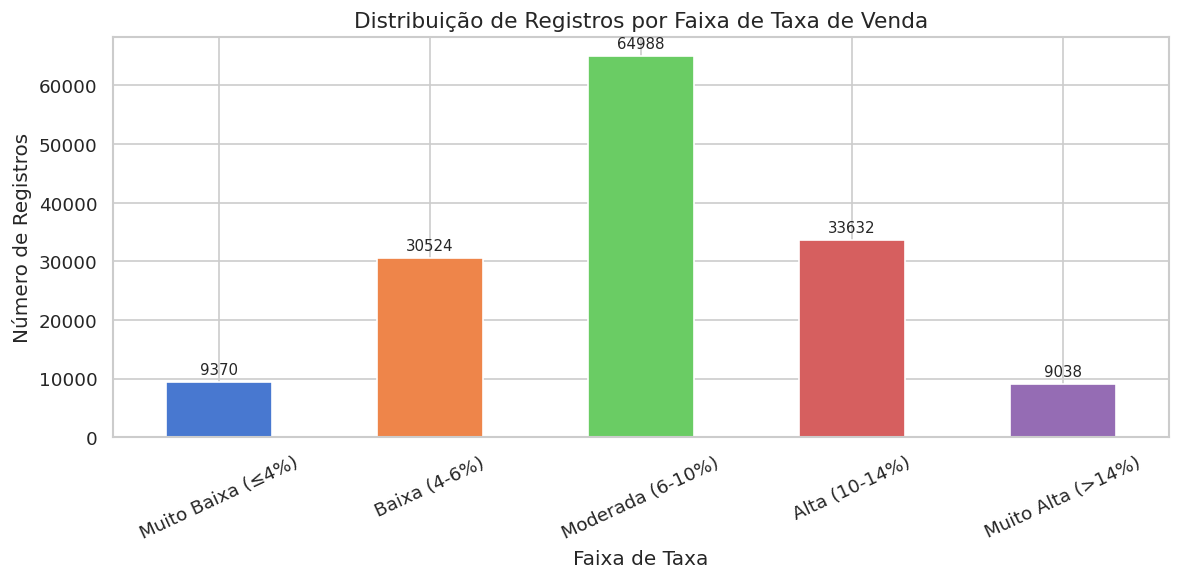

faixa_taxa_venda
Muito Baixa (≤4%)     9370
Baixa (4-6%)         30524
Moderada (6-10%)     64988
Alta (10-14%)        33632
Muito Alta (>14%)     9038


In [17]:
# Definir faixas baseadas no contexto do mercado brasileiro de renda fixa
faixas = [0, 4, 6, 10, 14, float("inf")]
rotulos = ["Muito Baixa (≤4%)", "Baixa (4-6%)", "Moderada (6-10%)",
           "Alta (10-14%)", "Muito Alta (>14%)"]

df_pre["faixa_taxa_venda"] = pd.cut(
    df_pre["Taxa Venda Manha"],
    bins=faixas,
    labels=rotulos,
    right=True,
)

distribuicao_faixas = df_pre["faixa_taxa_venda"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
distribuicao_faixas.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(rotulos)))
ax.set_title("Distribuição de Registros por Faixa de Taxa de Venda", fontsize=13)
ax.set_xlabel("Faixa de Taxa")
ax.set_ylabel("Número de Registros")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=9)
plt.tight_layout()
plt.show()

print(distribuicao_faixas.to_string())

**Análise após discretização:**

As faixas foram definidas com base nos patamares relevantes para o investidor de renda fixa no Brasil:

- **Muito Baixa (≤4%):** corresponde a taxas reais próximas de zero, típicas de períodos de juro estruturalmente baixo (2020–2021).
- **Baixa (4–6%):** faixa historicamente associada ao piso do ciclo monetário.
- **Moderada (6–10%):** faixa de equilíbrio histórico para títulos prefixados.
- **Alta (10–14%):** ciclos de aperto monetário mais severos.
- **Muito Alta (>14%):** eventos extremos (crise de 2002, pico de 2015–2016).

A concentração em **Moderada** e **Alta** reflete a realidade de um país com histórico de juros reais elevados.

### 5.9 One-Hot Encoding do Tipo de Título

Transformamos a coluna categórica `Tipo Titulo` em variáveis binárias (dummies). Isso é necessário para a maioria dos algoritmos de aprendizado de máquina, que não aceitam dados categóricos diretamente.

In [18]:
df_dummies = pd.get_dummies(df_pre["Tipo Titulo"], prefix="titulo", dtype=int)

print(f"Colunas geradas pelo one-hot encoding: {df_dummies.shape[1]}")
print(df_dummies.columns.tolist())
df_dummies.head()

Colunas geradas pelo one-hot encoding: 7
['titulo_Tesouro Educa+', 'titulo_Tesouro IGPM+ com Juros Semestrais', 'titulo_Tesouro IPCA+', 'titulo_Tesouro IPCA+ com Juros Semestrais', 'titulo_Tesouro Prefixado', 'titulo_Tesouro Prefixado com Juros Semestrais', 'titulo_Tesouro Renda+ Aposentadoria Extra']


,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,0
3,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0


In [19]:
# Dataset final com one-hot encoding integrado (excluindo a coluna original)
df_final = pd.concat(
    [df_pre.drop(columns=["Tipo Titulo"]), df_dummies],
    axis=1,
)

print(f"Dimensões do dataset final: {df_final.shape}")
df_final.head()

Dimensões do dataset final: (147877, 34)


,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha,dias_ate_vencimento,spread_taxa,spread_pu,...,PU Base Manha_std,dias_ate_vencimento_std,faixa_taxa_venda,titulo_Tesouro Educa+,titulo_Tesouro IGPM+ com Juros Semestrais,titulo_Tesouro IPCA+,titulo_Tesouro IPCA+ com Juros Semestrais,titulo_Tesouro Prefixado,titulo_Tesouro Prefixado com Juros Semestrais,titulo_Tesouro Renda+ Aposentadoria Extra
0,2011-01-01,2009-06-12,10.28,10.33,1039.94,1039.28,1038.87,568,0.05,-0.66,...,-0.647334,-0.784573,Alta (10-14%),0,0,0,0,0,1,0
1,2010-07-01,2009-06-12,9.58,9.62,1048.28,1047.91,1047.53,384,0.04,-0.37,...,-0.641091,-0.828845,Moderada (6-10%),0,0,0,0,0,1,0
2,2010-01-01,2009-06-12,9.06,9.10,1048.08,1047.87,1047.51,203,0.04,-0.21,...,-0.641106,-0.872395,Moderada (6-10%),0,0,0,0,0,1,0
3,2013-01-01,2009-06-12,12.00,12.06,990.45,988.89,988.45,1299,0.06,-1.56,...,-0.683677,-0.608690,Alta (10-14%),0,0,0,0,0,1,0
4,2014-01-01,2009-06-12,12.28,12.34,969.83,967.98,967.53,1664,0.06,-1.85,...,-0.698757,-0.520869,Alta (10-14%),0,0,0,0,0,1,0


O one-hot encoding gerou uma coluna binária para cada tipo de título. Ao utilizar esse dataset em modelos lineares, recomenda-se remover uma das colunas (dummy trap) para evitar multicolinearidade perfeita. Para árvores de decisão e modelos baseados em árvores, isso não é necessário.

---
## 4. Análise Exploratória dos Dados (EDA)

### 4.1 Estatísticas Descritivas

In [20]:
# Cópia de trabalho preservando o dataset original
df = df_final.iloc[:, 2:8].copy()

# Resumo estatístico das colunas numéricas
desc = df.describe().T
desc["median"] = df.describe(percentiles=[0.5]).T["50%"]
desc["mode"] = df[desc.index].mode().iloc[0]
desc = desc[["count", "mean", "std", "min", "25%", "median", "75%", "max", "mode"]]
desc.columns = ["N", "Média", "Desvio-Padrão", "Mín", "Q1", "Mediana", "Q3", "Máx", "Moda"]
desc

,N,Média,Desvio-Padrão,Mín,Q1,Mediana,Q3,Máx,Moda
Taxa Compra Manha,147877.0,8.117953,3.444891,-3.53,5.80,7.11,10.71,20.10,6.30
Taxa Venda Manha,147877.0,8.205913,3.433457,-3.41,5.90,7.21,10.79,20.13,5.85
PU Compra Manha,147877.0,1951.183338,1399.430737,0.00,933.61,1497.33,2647.20,9883.96,0.00
PU Venda Manha,147877.0,1936.903127,1387.569248,0.00,930.76,1486.14,2629.06,9808.85,0.00
PU Base Manha,147877.0,1936.921896,1387.313667,0.00,930.76,1485.86,2628.71,9802.55,0.00
dias_ate_vencimento,147877.0,3828.823373,4156.187909,1.00,830.00,2306.00,5518.00,22600.00,156.00


In [21]:
desc = df.describe().T
desc

,count,mean,std,min,25%,50%,75%,max
Taxa Compra Manha,147877.0,8.117953,3.444891,-3.53,5.80,7.11,10.71,20.10
Taxa Venda Manha,147877.0,8.205913,3.433457,-3.41,5.90,7.21,10.79,20.13
PU Compra Manha,147877.0,1951.183338,1399.430737,0.00,933.61,1497.33,2647.20,9883.96
PU Venda Manha,147877.0,1936.903127,1387.569248,0.00,930.76,1486.14,2629.06,9808.85
PU Base Manha,147877.0,1936.921896,1387.313667,0.00,930.76,1485.86,2628.71,9802.55
dias_ate_vencimento,147877.0,3828.823373,4156.187909,1.00,830.00,2306.00,5518.00,22600.00


In [22]:
df.describe(percentiles=[0.5]).T

,count,mean,std,min,50%,max
Taxa Compra Manha,147877.0,8.117953,3.444891,-3.53,7.11,20.10
Taxa Venda Manha,147877.0,8.205913,3.433457,-3.41,7.21,20.13
PU Compra Manha,147877.0,1951.183338,1399.430737,0.00,1497.33,9883.96
PU Venda Manha,147877.0,1936.903127,1387.569248,0.00,1486.14,9808.85
PU Base Manha,147877.0,1936.921896,1387.313667,0.00,1485.86,9802.55
dias_ate_vencimento,147877.0,3828.823373,4156.187909,1.00,2306.00,22600.00


**Análise das Estatísticas Descritivas:**

- As colunas de **taxa** apresentam valores entre -3.41% e aproximadamente 20.13% ao ano, refletindo o amplo período histórico do dataset (ciclos de alta e baixa da taxa Selic).
- Os **preços unitários** variam consideravelmente: Com desvio padrão de R$1399.30, indicando grande dispersão, o que é esperado dado o mix de títulos com diferentes prazos e indexadores.
- A **moda** das taxas e preços não é particularmente informativa dado o comportamento contínuo e evolutivo das séries, porém serve como referência de valor mais frequente no histórico.

### 4.2 Análise de Valores Faltantes e Inconsistentes

In [23]:
# Valores nulos genuínos
nulos = df.isnull().sum()

# Zeros nas colunas numéricas (valores ausentes mascarados)
colunas_numericas = df.select_dtypes(include="number").columns.tolist()
zeros = (df[colunas_numericas] == 0).sum()

print("Valores nulos por coluna:")
print(nulos.to_string())
print()
print("Zeros nas colunas numéricas:")
print(zeros.to_string())

Valores nulos por coluna:
Taxa Compra Manha      0
Taxa Venda Manha       0
PU Compra Manha        0
PU Venda Manha         0
PU Base Manha          0
dias_ate_vencimento    0

Zeros nas colunas numéricas:
Taxa Compra Manha      15
Taxa Venda Manha        1
PU Compra Manha        49
PU Venda Manha         48
PU Base Manha          29
dias_ate_vencimento     0


**Observações:**

- O dataset não apresenta valores `NaN` nativos, porém contém **zeros** nas colunas numéricas.
- A coluna `Tipo Titulo` não apresenta valores ausentes, o que é esperado.

### 4.4 Período Coberto pelo Dataset

In [24]:
data_min = df_pre["Data Base"].min()
data_max = df_pre["Data Base"].max()
periodo = (data_max - data_min).days

print("Período de oferta dos títulos:")
print(f"Data mais antiga : {data_min.strftime('%d/%m/%Y')}")
print(f"Data mais recente: {data_max.strftime('%d/%m/%Y')}")
print(f"Período coberto  : {periodo:,} dias ({periodo / 365.25:.1f} anos)")


janela_titulo = (
    df_pre.groupby("Tipo Titulo")["Data Base"]
    .agg(
        inicio_oferta="min",
        fim_oferta="max"
    )
    .sort_values("inicio_oferta")
    .reset_index()
)

janela_titulo["janela_dias"] = (
    janela_titulo["fim_oferta"] - janela_titulo["inicio_oferta"]
).dt.days

print("\n")
print("Janela de oferta por tipo de título:")
janela_titulo

Período de oferta dos títulos:
Data mais antiga : 31/12/2004
Data mais recente: 17/03/2026
Período coberto  : 7,746 dias (21.2 anos)


Janela de oferta por tipo de título:


,Tipo Titulo,inicio_oferta,fim_oferta,janela_dias
0,Tesouro IGPM+ com Juros Semestrais,2004-12-31,2026-03-17,7746
1,Tesouro IPCA+ com Juros Semestrais,2004-12-31,2026-03-17,7746
2,Tesouro Prefixado,2004-12-31,2026-03-17,7746
3,Tesouro Prefixado com Juros Semestrais,2004-12-31,2026-03-17,7746
4,Tesouro IPCA+,2005-07-18,2026-03-17,7547
5,Tesouro Renda+ Aposentadoria Extra,2023-01-30,2026-03-17,1142
6,Tesouro Educa+,2023-08-01,2026-03-17,959


A janela temporal de oferta não é homogênea entre os tipos de título e isso afeta comparações diretas de representatividade. Enquanto Tesouro Prefixado, Tesouro Prefixado com Juros Semestrais, Tesouro IPCA+ com Juros Semestrais e Tesouro IGPM+ com Juros Semestrais aparecem desde 31/12/2004 até 16/03/2026, o Tesouro IPCA+ inicia em 18/07/2005, e os títulos Tesouro Renda+ Aposentadoria Extra e Tesouro Educa+ surgem apenas a partir de 2023. Portanto, análises baseadas em contagens absolutas tendem a favorecer títulos com maior tempo de exposição no dataset.  
Para comparações mais justas, os dados serão ponderados pela janela temporal de cada tipo de título.

### 4.3 Distribuição dos Tipos de Título

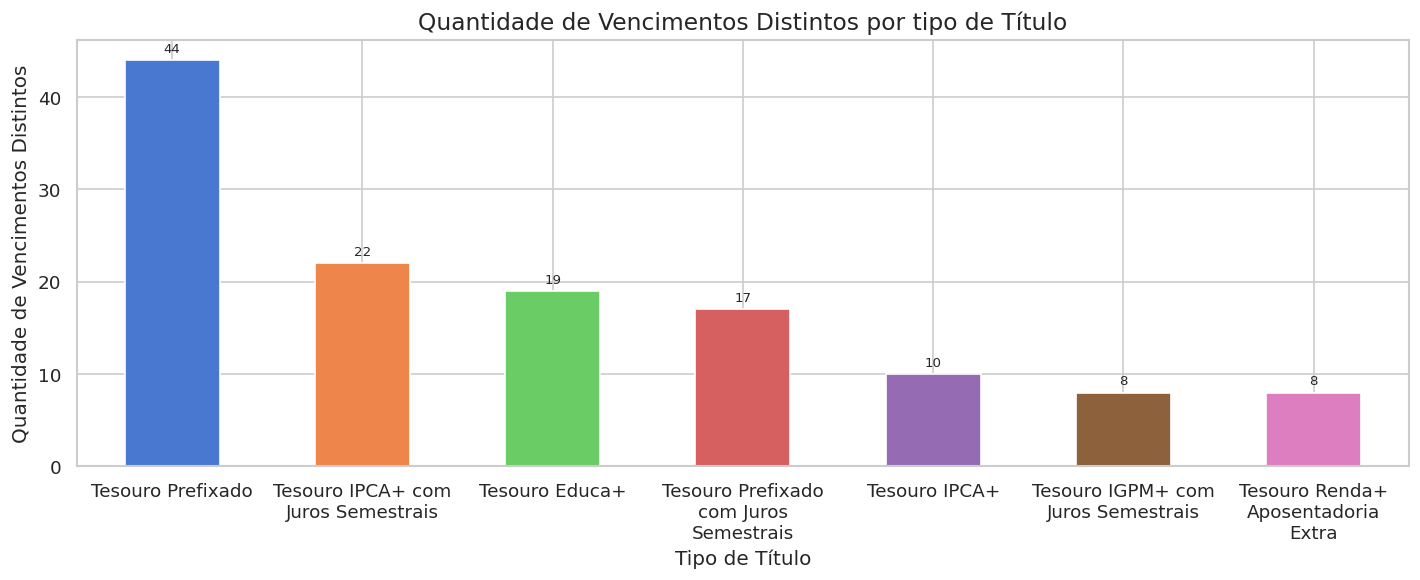

,Tipo Título,Vencimentos Distintos,Janela de Oferta (dias),razao_vencimentos_janela
2,Tesouro Prefixado,44,7746,0.005680
1,Tesouro IPCA+ com Juros Semestrais,22,7746,0.002840
6,Tesouro Educa+,19,959,0.019812
3,Tesouro Prefixado com Juros Semestrais,17,7746,0.002195
4,Tesouro IPCA+,10,7547,0.001325
0,Tesouro IGPM+ com Juros Semestrais,8,7746,0.001033
5,Tesouro Renda+ Aposentadoria Extra,8,1142,0.007005


In [25]:
from textwrap import fill
valores_unicos = (df_pre["Tipo Titulo"] + " - " + df_pre["Data Vencimento"].dt.strftime("%Y-%m-%d")).unique()

valores_unicos = pd.Series([i[:-13] for i in valores_unicos])

contagem_tipos = valores_unicos.value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
contagem_tipos.plot(kind="bar", ax=ax, color=sns.color_palette("muted", len(contagem_tipos)))
ax.set_title("Quantidade de Vencimentos Distintos por tipo de Título", fontsize=14)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Quantidade de Vencimentos Distintos")

labels_quebrados = [fill(tipo, width=18) for tipo in contagem_tipos.index]
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(labels_quebrados, rotation=0, ha="center")

# ax.tick_params(axis="x", rotation=90)
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

tabela = pd.DataFrame(contagem_tipos).merge(janela_titulo[["Tipo Titulo",  "janela_dias"]], left_index=True, right_on="Tipo Titulo")[['Tipo Titulo', 'count','janela_dias']]
tabela.columns = ["Tipo Título", "Vencimentos Distintos", "Janela de Oferta (dias)"]
tabela['razao_vencimentos_janela'] = tabela['Vencimentos Distintos'] / tabela['Janela de Oferta (dias)']
tabela

**Análise:**

O gráfico revela que determinados tipos de título possuem muito mais registros que outros, mas temos que ponderar pelo periodo de oferta do título. O mais representado é o `Tesouro Prefixado` com 44 titulos com vencimentos distintos entre os títulos com 7745 dias de oferta. Quanod se pondera o número de títulos com vencimentos distintos e a quantidade de dias de ofertatados, o `Tesouro Educa+` e o `Tesouro Renda+ Aposentadoria Extra` são os mais representaitivos, pois apresentão uma quantidade significativa de títulos com vencimentos distintos em relação ao período relativo de oferta. Isso pode indicar uma estratégia do tesouro direto de dar preferencia a esses tipos de títulos, pois o retorno do investimento desses titulos ocorem durante um período de tempo, ao invez de ocorrerem em um momento específico onde o retorno do investimento ocorre no momento do vencimento.

### 4.5 Distribuição das Taxas de Compra e Venda

Os histogramas a seguir mostram a distribuição geral das taxas de compra e venda da manhã.

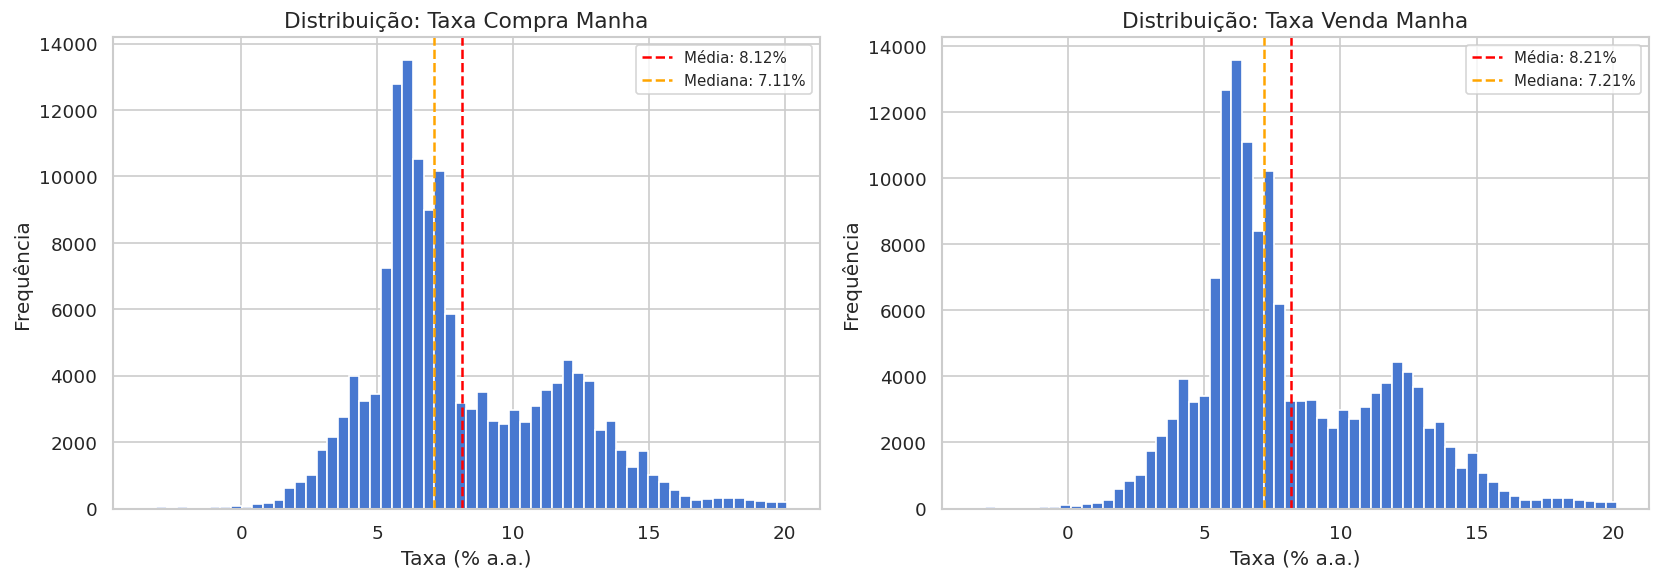

In [26]:
taxas = df_pre[["Taxa Compra Manha", "Taxa Venda Manha"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, coluna in zip(axes, ["Taxa Compra Manha", "Taxa Venda Manha"]):
    ax.hist(taxas[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[0])
    ax.set_title(f"Distribuição: {coluna}", fontsize=13)
    ax.set_xlabel("Taxa (% a.a.)")
    ax.set_ylabel("Frequência")
    ax.axvline(taxas[coluna].mean(), color="red", linestyle="--", label=f"Média: {taxas[coluna].mean():.2f}%")
    ax.axvline(taxas[coluna].median(), color="orange", linestyle="--", label=f"Mediana: {taxas[coluna].median():.2f}%")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [27]:
stat, p_value = stats.wilcoxon(df_pre["Taxa Compra Manha"], df_pre["Taxa Venda Manha"], zero_method='wilcox', correction=False, alternative='two-sided')
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

Estatística de teste: 0.0
Valor-p: 0.00000


**Análise:**

As distribuições das taxas de compra e venda apresentam perfil **multimodal**, com concentrações em diferentes faixas de rentabilidade. Isso é esperado num dataset que mistura tipos distintos de título (prefixados, IPCA+, Selic) ao longo de diferentes ciclos econômicos. A **média** é ligeiramente superior à **mediana**, indicando assimetria positiva — há alguns períodos históricos com taxas muito elevadas (ex.: 2015–2016, quando a taxa Selic chegou a 14,25% a.a.) que puxam a média para cima.  
Apesar da semelhança entre as distribuições de compra e venda, o teste de Wilcoxon confirma que o *spread* entre as duas taxas é significativo. Isso é consistente com a prática de mercado, onde a taxa de venda é geralmente um pouco superior à taxa de compra para cobrir custos operacionais e garantir margem de lucro.

### 4.6 Distribuição dos Preços Unitários

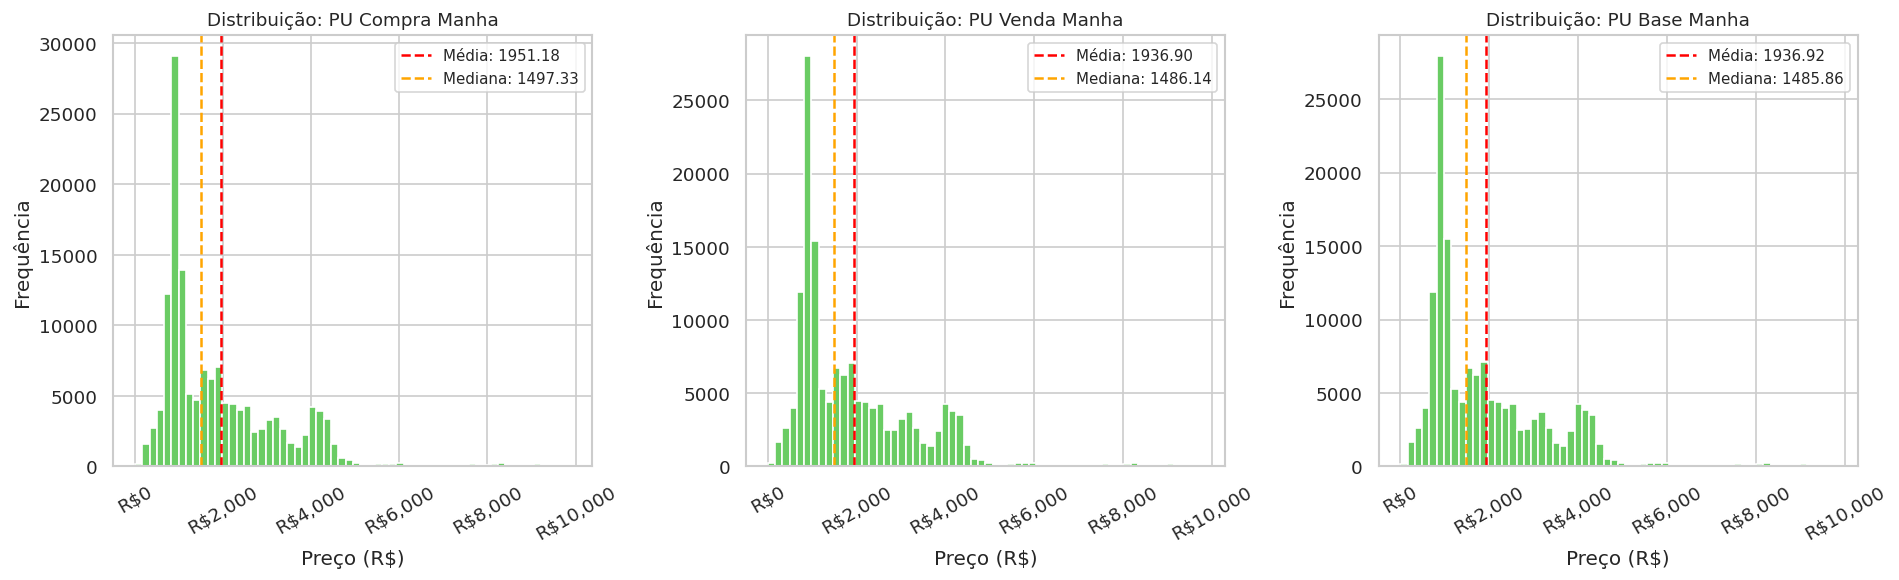

In [28]:
pus = df_pre[["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, coluna in zip(axes, ["PU Compra Manha", "PU Venda Manha", "PU Base Manha"]):
    ax.hist(pus[coluna], bins=60, edgecolor="white", color=sns.color_palette("muted")[2])
    ax.set_title(f"Distribuição: {coluna}", fontsize=11)
    ax.set_xlabel("Preço (R$)")
    ax.set_ylabel("Frequência")
    ax.axvline(pus[coluna].mean(), color="red", linestyle="--", label=f"Média: {pus[coluna].mean():.2f}")
    ax.axvline(pus[coluna].median(), color="orange", linestyle="--", label=f"Mediana: {pus[coluna].median():.2f}")
    ax.legend(fontsize=9)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R${x:,.0f}"))
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [29]:
stat, p_value = stats.friedmanchisquare(
    df_pre["PU Compra Manha"],
    df_pre["PU Venda Manha"],
    df_pre["PU Base Manha"]
)
print("Teste de Friedman para comparação de medianas entre PUs:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")
print("\n")

stat, p_value = stats.kstest(
    df_pre["PU Compra Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Compra Manha"].std(), 0, df_pre["PU Compra Manha"].mean())
)
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Compra Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

stat, p_value = stats.kstest(
    df_pre["PU Venda Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Venda Manha"].std(), 0, df_pre["PU Venda Manha"].mean())
)

print("\n")
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Venda Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

stat, p_value = stats.kstest(
    df_pre["PU Base Manha"],
    cdf = stats.lognorm.cdf,
    args = (df_pre["PU Base Manha"].std(), 0, df_pre["PU Base Manha"].mean())
)

print("\n")
print("Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Base Manha:")
print(f"Estatística de teste: {stat}")
print(f"Valor-p: {p_value:.5f}")

Teste de Friedman para comparação de medianas entre PUs:
Estatística de teste: 272630.7798613658
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Compra Manha:
Estatística de teste: 0.4995374729188178
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Venda Manha:
Estatística de teste: 0.4995336002913575
Valor-p: 0.00000


Teste de Kolmogorov-Smirnov para ajuste à distribuição log-normal para PU Base Manha:
Estatística de teste: 0.49953370191008695
Valor-p: 0.00000


**Análise:**

As distribuições dos preços unitários são fortemente assimétricas, com cauda longa à direita. A maior concentração de registros ocorre em valores relativamente baixos (próximos a R$ 0–R$ 5.000).  
Apesar da assimetria, uma transformação logarítmica não seria útil para alcançar a normalidade nos dados, como indicado pelo teste de Kolmogorov-Smirnov. A normalidade é um pressuposto importante para muitos modelos preditivos, e a falha em alcançar a normalidade implica que técnicas de modelagem robustas ou não paramétricas podem ser mais adequadas para este dataset.  
Apesar da semelhança entre as distribuições, o teste de Friedman indica que há diferenças estatisticamente significativas entre os preços unitários de compra e venda, o que é esperado dado o spread de mercado. A diferença entre os preços unitários de compra e venda é consistente com a prática de mercado, onde o preço de venda é geralmente um pouco superior ao preço de compra para cobrir custos operacionais e garantir margem de lucro.

### 4.7 Análise por Tipo de Título

#### 4.7.1 Séries Temporais de Taxa de Venda

A evolução temporal das taxas é o principal ângulo analítico deste dataset. Analisamos a **Taxa Venda Manha** separada por tipo de título para capturar os ciclos econômicos.

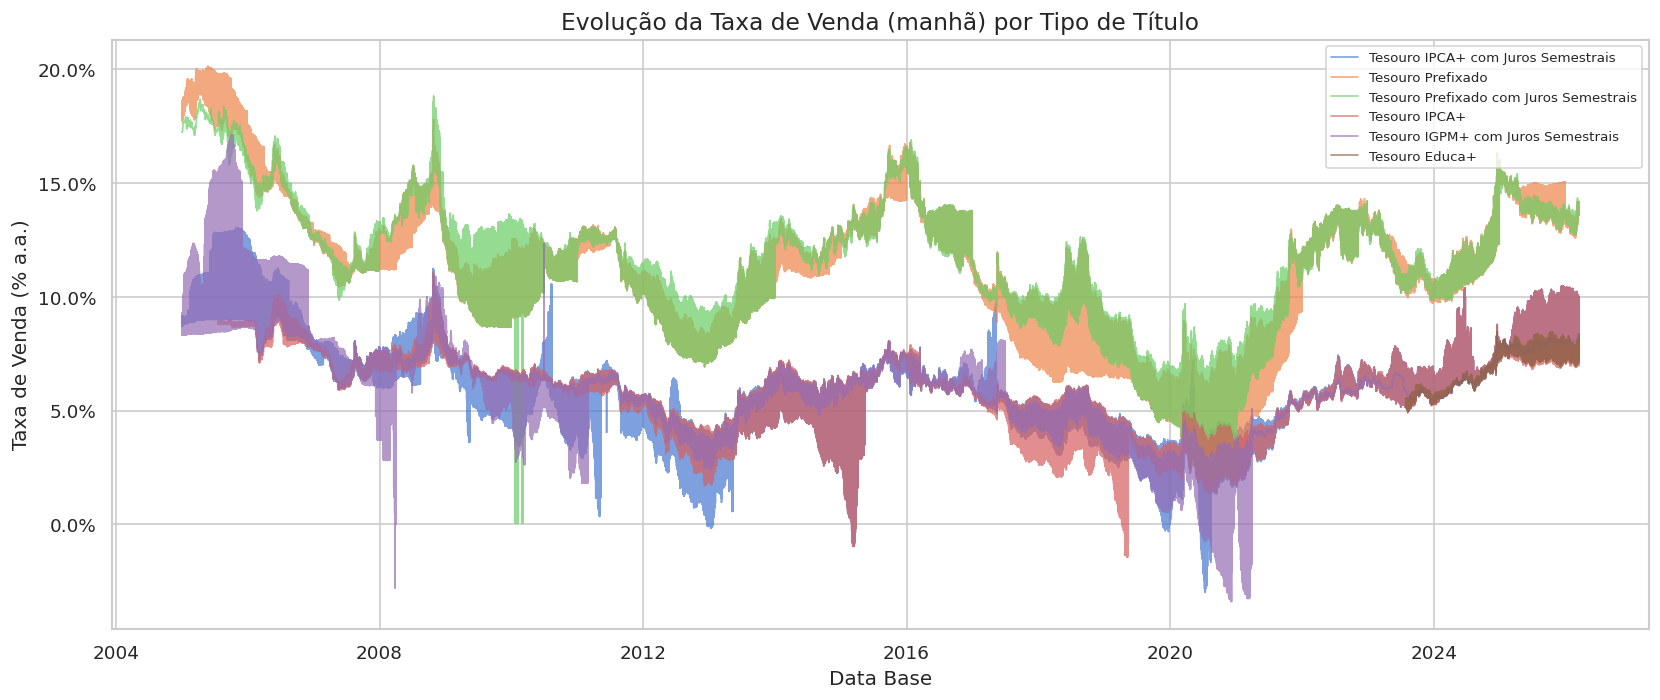

In [30]:
# Filtrar apenas registros com taxa válida
df_taxa = df_pre.copy()

# Selecionar os 6 tipos com mais registros para clareza visual
top_tipos = df_taxa["Tipo Titulo"].value_counts().head(6).index.tolist()
df_top = df_taxa[df_taxa["Tipo Titulo"].isin(top_tipos)]

fig, ax = plt.subplots(figsize=(14, 6))
for tipo in top_tipos:
    subset = df_top[df_top["Tipo Titulo"] == tipo].sort_values("Data Base")
    ax.plot(subset["Data Base"], subset["Taxa Venda Manha"], label=tipo, alpha=0.7, linewidth=1)

ax.set_title("Evolução da Taxa de Venda (manhã) por Tipo de Título", fontsize=14)
ax.set_xlabel("Data Base")
ax.set_ylabel("Taxa de Venda (% a.a.)")
ax.legend(fontsize=8, loc="upper right")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.1f}%"))
plt.tight_layout()
plt.show()

**Análise:**

A série temporal revela claramente os **ciclos de política monetária** brasileira:

- **2002–2003:** Elevação abrupta das taxas no período pré-eleição presidencial, com o mercado precificando risco político.
- **2006–2012:** Período de relativa estabilidade e gradual queda das taxas, especialmente no governo Lula.
- **2015–2016:** Novo ciclo de alta, com a taxa Selic atingindo 14,25% a.a. em resposta à crise fiscal e recessão.
- **2017–2019:** Queda expressiva após a recessão, com taxas chegando ao menor nível histórico em 2020.
- **2021–2023:** Nova alta acelerada em resposta à inflação pós-pandemia.

Os títulos indexados (Tesouro IPCA+, Tesouro IPCA+ com Juros Semestrais, Tesouro IGPM+ e Tesouro IGPM+ com Juros Semestrais e Tesouro Educa+) apresentam taxas nominalmente menores, que os títulos prefixados, pois apresentão prazos muito longos que não permitem a modelagem dos riscos de mercado, então eles são indexados a um índice de inflação como IPCA ou IGPM. Já os títulos prefixados embutem a expectativas de inflação futura, o que resulta em taxas mais elevadas.

#### 4.7.2 Análise de Sazonalidade — Melhores Dias para Comprar

A sazonalidade em mercados financeiros pode revelar padrões sistemáticos na Taxa Compra entre diferentes dias da semana e do mês. Esta análise investiga se há dias específicos que oferecem melhores oportunidades para compra de títulos do Tesouro Direto.

In [45]:
# Análise agregada por dia da semana
sazon_semana = df_pre.groupby("dia_semana").agg({
    "Taxa Compra Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)

sazon_semana.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_semana = sazon_semana.reindex(["Segunda", "Terça", "Quarta", "Quinta", "Sexta", "Sábado", "Domingo"])

print("Estatísticas por Dia da Semana:")
print(sazon_semana.to_string())
print()

# Identificar o melhor dia para comprar (menor taxa = melhor para comprador)
melhor_dia = sazon_semana["Taxa Média"].idxmax()
print(f"\n✓ Dia com MAIOR taxa média: {melhor_dia} ({sazon_semana.loc[melhor_dia, 'Taxa Média']:.4f}%)")
print(f"✓ Menor spread médio: {sazon_semana['Spread Médio'].idxmin()} ({sazon_semana['Spread Médio'].min():.6f} p.p.)")

Estatísticas por Dia da Semana:
            Taxa Média  Taxa Mediana  Desvio Padrão  N Registros  Spread Médio
dia_semana                                                                    
Segunda         8.1217          7.10         3.4453      29466.0        0.0880
Terça           8.1182          7.10         3.4440      29569.0        0.0881
Quarta          8.1082          7.11         3.4393      29995.0        0.0878
Quinta          8.1107          7.11         3.4474      29393.0        0.0879
Sexta           8.1312          7.12         3.4487      29454.0        0.0880
Sábado             NaN           NaN            NaN          NaN           NaN
Domingo            NaN           NaN            NaN          NaN           NaN


✓ Dia com MAIOR taxa média: Sexta (8.1312%)
✓ Menor spread médio: Quarta (0.087800 p.p.)


Apesar da Sexta-feira apresentar a maior taxa média, os desvios padrão observados são elevados, o que não permite concluir que a Sexta-feira é o melhor dia para comprar.

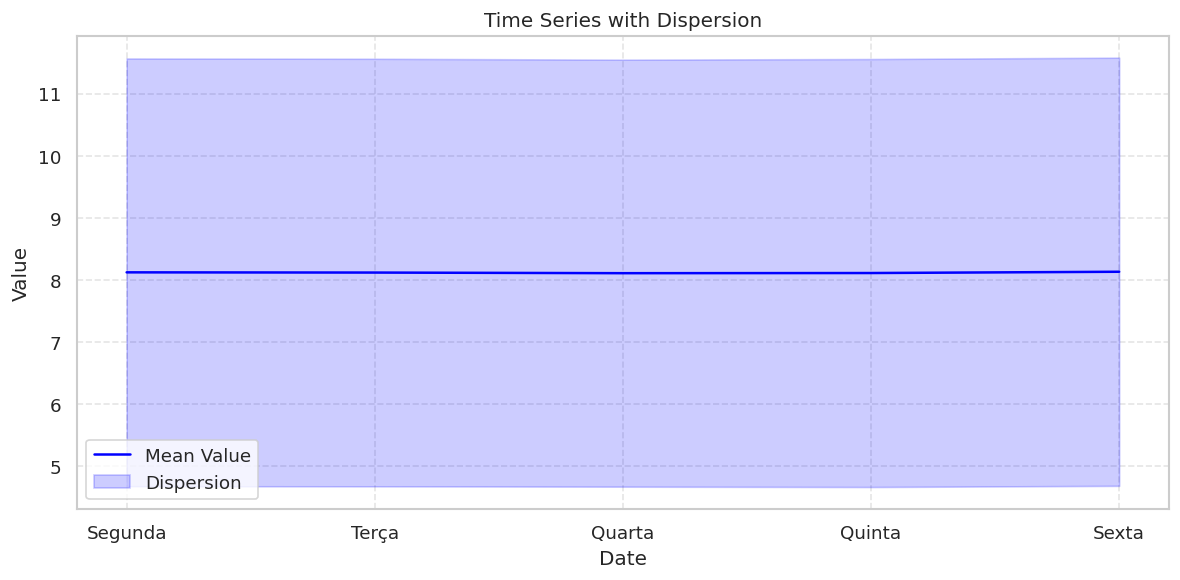

In [59]:
dates = pd.date_range(start="2024-01-01", periods=50, freq="D")
values = np.cumsum(np.random.randn(50)) + 10
std_dev = np.random.rand(50) * 2  # dispersion

# Create DataFrame
df = pd.DataFrame({"Date": dates, "Value": values, "StdDev": std_dev})

# Plot
plt.figure(figsize=(10, 5))
plt.plot(sazon_semana.index, sazon_semana["Taxa Média"], label="Mean Value", color="blue")
plt.fill_between(sazon_semana.index,
                 sazon_semana["Taxa Média"] - sazon_semana["Desvio Padrão"],
                 sazon_semana["Taxa Média"] + sazon_semana["Desvio Padrão"],
                 color="blue", alpha=0.2, label="Dispersion")

plt.title("Time Series with Dispersion")
plt.xlabel("Date")
plt.ylabel("Value")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

O gráfico de dispersão é pouco informativo devido a grande dispersão dos dados.  
Realizamos um teste de ANOVA para verificar se as diferenças entre os dias da semana são estatisticamente significativas, apesar de saber que se trata de uma serie temporal e que a ANOVA não é o teste ideal para dados com autocorrelação temporal, mas mesmo assim, os resultados da ANOVA poderá indicar se há uma possivel diferenças entre os dias da semana.

In [41]:
stat, p_value = stats.f_oneway(
    df_pre[df_pre["dia_semana"] == "Segunda"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Terça"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Quarta"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Quinta"]["Taxa Compra Manha"],
    df_pre[df_pre["dia_semana"] == "Sexta"]["Taxa Compra Manha"],
)

print(f"\nTeste ANOVA para diferença de taxas entre dias da semana:")
print(f"Estatística de teste: {stat:.4f}")
print(f"Valor-p: {p_value:.5f}")


Teste ANOVA para diferença de taxas entre dias da semana:
Estatística de teste: 0.2099
Valor-p: 0.93308


Não foram encontradas diferenças estatisticamente significativas entre os dias da semana, o que sugere que a sazonalidade semanal não é um fator relevante para a determinação das taxas de compra. Portanto, não há evidências suficientes para recomendar um dia específico da semana como o melhor momento para comprar títulos do Tesouro Direto com base nas taxas de compra.

In [50]:
# Agrupar em períodos do mês (início, meio, fim)
def classificar_periodo_mes(dia):
    if dia <= 10:
        return "Início (1-10)"
    elif dia <= 20:
        return "Meio (11-20)"
    else:
        return "Fim (21-31)"

df_pre["periodo_mes"] = df_pre["dia_mes"].apply(classificar_periodo_mes)

# Análise por período do mês
sazon_mes = df_pre.groupby("periodo_mes").agg({
    "Taxa Venda Manha": ["mean", "median", "std", "count"],
    "spread_taxa": "mean",
}).round(4)

sazon_mes.columns = ["Taxa Média", "Taxa Mediana", "Desvio Padrão", "N Registros", "Spread Médio"]
sazon_mes = sazon_mes.reindex(["Início (1-10)", "Meio (11-20)", "Fim (21-31)"])

print("\nEstatísticas por Período do Mês:")
print(sazon_mes.to_string())
print()

melhor_periodo = sazon_mes["Taxa Média"].idxmax()
print(f"\n✓ Período com MAIOR taxa média: {melhor_periodo} ({sazon_mes.loc[melhor_periodo, 'Taxa Média']:.4f}%)")


Estatísticas por Período do Mês:
               Taxa Média  Taxa Mediana  Desvio Padrão  N Registros  Spread Médio
periodo_mes                                                                      
Início (1-10)      8.1883          7.19         3.4270        48271        0.0883
Meio (11-20)       8.2032          7.21         3.4261        48963        0.0880
Fim (21-31)        8.2254          7.23         3.4467        50643        0.0876


✓ Período com MAIOR taxa média: Fim (21-31) (8.2254%)


### 4.8 Análise de Correlação entre Atributos Numéricos

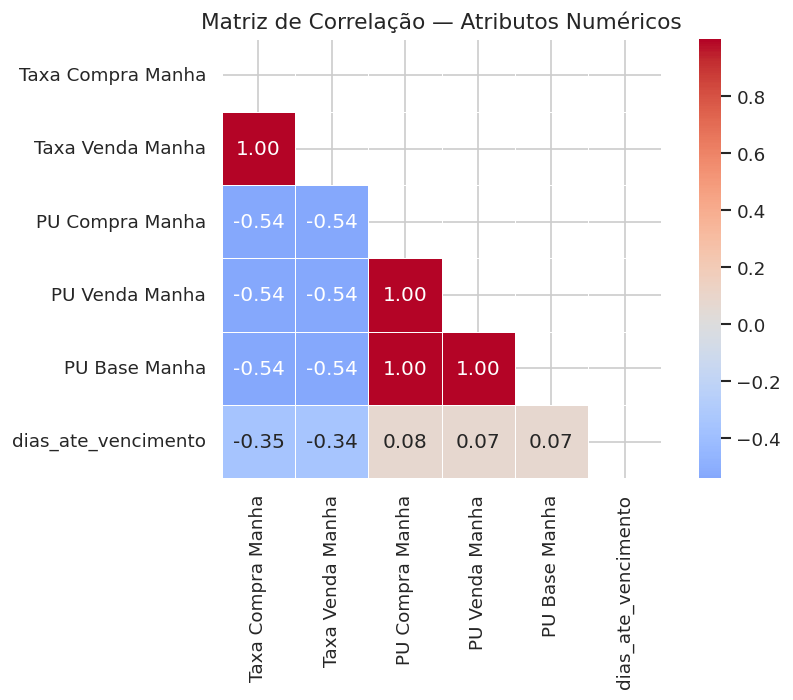

In [31]:
# Substituir zeros por NaN antes de calcular correlação
df_corr = df_pre[colunas_numericas].replace(0, np.nan)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(df_corr.corr(), dtype=bool))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    mask=mask,
    ax=ax,
    square=True,
    linewidths=0.5,
)
ax.set_title("Matriz de Correlação — Atributos Numéricos", fontsize=13)
plt.tight_layout()
plt.show()

**Análise:**

A matriz de correlação revela padrões importantes:

- **Correlação fortíssima (≈ 1,0) entre PU Compra, PU Venda e PU Base:** os três preços unitários são quase idênticos, diferindo apenas pelo pequeno spread de negociação. Em modelos futuros, utilizar apenas um deles evita multicolinearidade.
- **Correlação fortíssima entre Taxa Compra e Taxa Venda:** assim como os PUs, o spread entre as taxas de compra e venda é mínimo.
- **Correlação negativa entre taxas e preços unitários:** confirma a relação inversa fundamental de renda fixa — quando as taxas sobem, os preços dos títulos caem, e vice-versa.
- **Correlação negativa entre dias até vencimento e taxas:** títulos com vencimentos mais longos tendem a oferecer taxas mais baixas.

As demais correlações são fracas, então não serão consideradas relevantes para a análise.

### 4.9 Boxplot das Taxas por Tipo de Título

O boxplot permite comparar a dispersão e os outliers das taxas entre os diferentes tipos de título.

In [45]:
df_box = df[df["Taxa Venda Manha"] > 0].copy()
# Ordenar por mediana para facilitar a leitura
ordem = (
    df_box.groupby("Tipo Titulo")["Taxa Venda Manha"]
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(
    data=df_box,
    x="Tipo Titulo",
    y="Taxa Venda Manha",
    order=ordem,
    palette="muted",
    ax=ax,
    flierprops={"marker": ".", "alpha": 0.3, "markersize": 3},
)
ax.set_title("Distribuição da Taxa de Venda (manhã) por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Taxa de Venda (% a.a.)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}%"))
plt.tight_layout()
plt.show()

KeyError: 'Tipo Titulo'

**Análise:**

O boxplot destaca diferenças estruturais entre os tipos de título:

- **LFT / Tesouro Selic:** apresenta a menor dispersão de taxas, pois é pós-fixado e sua taxa acompanha a Selic diretamente. Os "outliers" correspondem a períodos de estresse no mercado.
- **NTN-F / Tesouro Prefixado:** maior dispersão, refletindo que os preços deste título sofrem com a incerteza sobre a trajetória futura dos juros.
- **NTN-B / Tesouro IPCA+:** mediana de taxa real em torno de 5–7% a.a., com picos em momentos de aversão a risco. A variabilidade é considerável, especialmente para títulos de longo prazo.
- Títulos com nomes mais antigos (LTN, NTN-B Principal) podem ter distribuições distintas por cobrir períodos históricos diferentes.

### 4.10 Análise do Spread entre Taxa de Compra e Venda

In [ ]:
df_spread = df[(df["Taxa Compra Manha"] > 0) & (df["Taxa Venda Manha"] > 0)].copy()
df_spread["spread_taxa"] = df_spread["Taxa Venda Manha"] - df_spread["Taxa Compra Manha"]

# Spread médio por tipo de título
spread_medio = (
    df_spread.groupby("Tipo Titulo")["spread_taxa"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
spread_medio.plot(kind="bar", ax=ax, color=sns.color_palette("muted")[4])
ax.set_title("Spread Médio entre Taxa de Venda e Taxa de Compra por Tipo de Título", fontsize=13)
ax.set_xlabel("Tipo de Título")
ax.set_ylabel("Spread Médio (p.p.)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.2f} p.p."))
plt.tight_layout()
plt.show()

print("Spread médio (pontos percentuais):")
print(spread_medio.round(4).to_string())

**Análise:**

O spread entre as taxas de compra e venda representa o custo implícito de negociação no Tesouro Direto. Os resultados mostram:

- O spread é **muito pequeno** para todos os tipos (geralmente abaixo de 0,10 p.p.), o que evidencia a eficiência e a liquidez razoável do programa.
- Títulos de prazo mais longo tendem a ter spreads ligeiramente maiores, refletindo maior incerteza sobre o valor futuro.
- Picos de spread ocorrem em momentos de stress de mercado, quando a diferença entre oferta e demanda se amplia.

---
## 6. Checklist — Respostas

### Definição do Problema

| Pergunta | Resposta |
|---|---|
| Qual é a descrição do problema? | Analisar o histórico de preços e taxas dos títulos do Tesouro Direto para entender padrões, tendências e comportamento ao longo de ciclos econômicos. |
| Supervisionado ou não supervisionado? | **Não supervisionado** nesta etapa (EDA e pré-processamento); pode ser reformulado como supervisionado para previsão de taxas. |
| Hipóteses/premissas? | Ver Seção 1.3: H1–H4 sobre correlação com macroeconomia, volatilidade por tipo, relação inversa taxa-preço e prêmio por prazo. |
| Restrições para seleção dos dados? | Todos os registros históricos são usados; apenas colunas de período da manhã são analisadas; zeros são tratados como ausentes. |
| Atributos definidos? | Ver Seção 1.5: 8 atributos originais + 6 derivados criados no pré-processamento. |

### Análise de Dados

| Pergunta | Resposta |
|---|---|
| Quantos atributos e instâncias? | Verificado na Seção 3.1 (dimensões do dataset). |
| Tipos de dados? | `Data Base` e `Data Vencimento`: datetime; `Tipo Titulo`: object; demais: float64. |
| Primeiras linhas chamam atenção? | Zeros nas colunas numéricas indicam ausentes mascarados; dois sistemas de nomenclatura (pré e pós-2015). |
| Valores faltantes/discrepantes? | Zeros mascarando ausências (tratados na Seção 5.2); nenhum NaN nativo no dataset original. |
| Resumo estatístico realizado? | Sim — Seção 4.1. |
| Distribuição de cada atributo? | Sim — Seções 4.3 (categórico), 4.5 (taxas), 4.6 (PUs). |
| Análise individual e combinada? | Sim — séries temporais (4.7), correlação (4.8), boxplot (4.9), spread (4.10). |

### Pré-processamento

| Operação | Realizada? | Seção |
|---|---|---|
| Substituição de zeros por NaN | ✅ | 5.2 |
| Remoção de registros completamente ausentes | ✅ | 5.3 |
| Engenharia de atributos | ✅ | 5.4 |
| Normalização (Min-Max) | ✅ | 5.6 |
| Padronização (Z-score) | ✅ | 5.7 |
| Discretização de taxas | ✅ | 5.8 |
| One-hot encoding | ✅ | 5.9 |
| Análise revisitada | ✅ | 5.10 |

---
## 7. Conclusão

Este trabalho percorreu as principais etapas de um projeto de ciência de dados aplicado ao dataset de **Taxas dos Títulos Ofertados pelo Tesouro Direto**.

### Principais Achados

1. **Ciclos econômicos bem visíveis:** a série histórica reflete com fidelidade os ciclos de política monetária brasileira, com altas expressivas em 2002–2003, 2015–2016 e 2021–2022.

2. **Ausentes mascarados:** o dataset não possui NaN nativos, mas contém zeros que representam dias sem negociação. O tratamento correto desses valores é fundamental para qualquer análise subsequente.

3. **Correlação inversa taxa × preço:** confirmada na matriz de correlação, esta relação é estrutural em renda fixa e deve ser considerada em qualquer modelo preditivo.

4. **Alta colinearidade entre PUs:** os três preços unitários (compra, venda, base) são quase redundantes. Em etapas de modelagem, recomenda-se utilizar apenas um deles.

5. **Diversidade de títulos:** o dataset mistura produtos com características e históricos distintos, exigindo análises segmentadas por tipo de título para conclusões válidas.

### Próximos Passos

- **Modelagem preditiva:** com os dados pré-processados, é possível construir modelos para prever a taxa de um título em função de características como prazo, tipo e momento econômico (ex.: regressão linear, gradient boosting).
- **Análise de cluster:** identificar grupos de títulos com comportamentos similares de taxa ao longo do tempo.
- **Análise de sazonalidade:** investigar se há padrões mensais ou anuais nas taxas dos títulos.
- **Integração com dados macroeconômicos:** combinar com séries históricas da Selic, IPCA e PIB para enriquecer a análise causal.

---
*Notebook desenvolvido para a disciplina Análise de Dados e Boas Práticas — Especialização em Ciência de Dados, PUC. Todos os dados são públicos e disponibilizados pelo Tesouro Nacional.*